# CSCA-5642, NLP with Disaster Tweets


# Brief description of the problem and data¶

In this notebook I’m training a few RNN models to predict which Tweets are about real disasters and which ones are not.

## Dataset

The dataset consists of two csv files: the labeled one used for model training and validation, and the unlabeled for prediction, for participating in the competition.
* **train.csv**: 7613 twits, 987712 B
* **test.csv**: 3263 twits, 420783 B

The columns in files:
* `id` - a unique identifier for each tweet
* `text` - the text of the tweet
* `location` - the location the tweet was sent from (may be blank)
* `keyword` - a particular keyword from the tweet (may be blank)
* `target` - in **train.csv** only, this denotes whether a tweet is about a real disaster (`1`) or not (`0`)

## Additional datasets/models

To jumpstart with pretrained embeddings I'm relying on two additional models:
* `glove-twitter-100d` - GloVe by Stanford for single word embeddings
* `all-MiniLM-L6-v2` - a sentence transformer by Microsoft Research/Hugging Face

## Additional python packages
* `contractions` - to expand English language contractions
* `spellchecker` - to correct very typos

In [1]:
DATASET_DIR = '/kaggle/input/nlp-getting-started'
GLOVE_EMB = '/kaggle/input/glove-twitter-100d/glove.twitter.27B.100d.txt'
MINILM_L6V2 = '/kaggle/input/all-minilm-l6-v2/transformers/default/1/all-MiniLM-L6-v2'
WORKING_DIR = '/kaggle/working/'

# Exploratory Data Analysis (EDA)

In [2]:
from os import path
import pandas as pd

train_df = pd.read_csv(path.join(DATASET_DIR, 'train.csv'))
test_df = pd.read_csv(path.join(DATASET_DIR, 'test.csv'))

In [3]:
train_df

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


I don't plan any special handling of NaN, let's just impute empty strings to simplify the processing down the road.

In [4]:
train_df = train_df.fillna('')
test_df = test_df.fillna('')

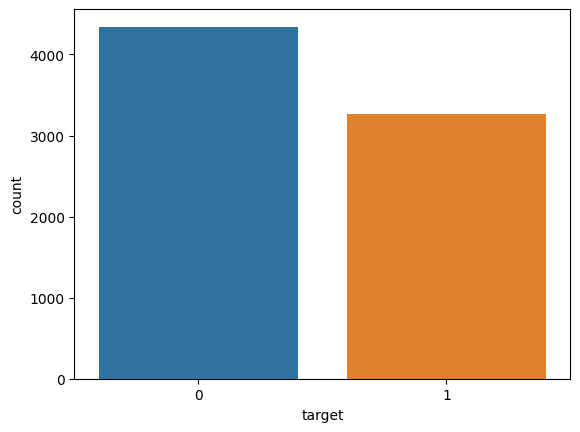

target==0: 4342
target==1: 3271


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='target', data=train_df)
plt.show()

print('target==0:', train_df[train_df['target']==0].shape[0])
print('target==1:', train_df[train_df['target']==1].shape[0])

Let's look at the basic tweets properties (not showing corresponding characteristics of test_df, but they have very similar distribution)

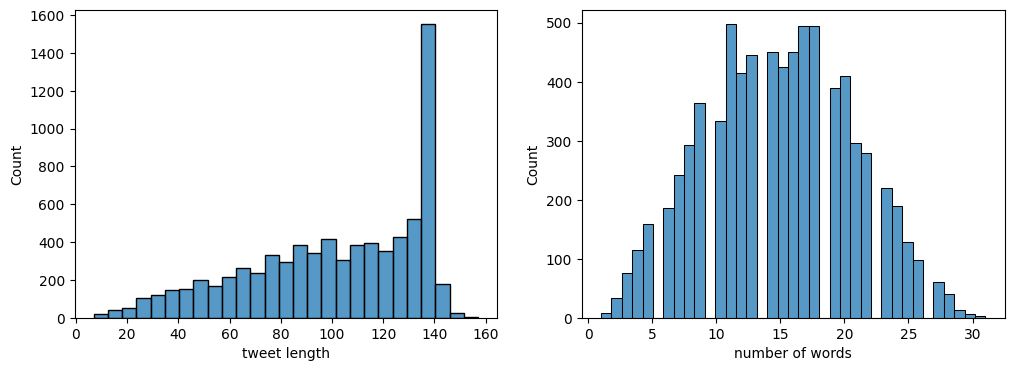

In [6]:
#import warnings
#warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

fig, axes = plt.subplots(1,2,figsize=(12,4))

sns.histplot(data=train_df['text'].apply(len), ax=axes[0])
axes[0].set_xlabel('tweet length')

sns.histplot(data=train_df['text'].apply(lambda t: len(t.split())), ax=axes[1])
axes[1].set_xlabel('number of words')

plt.show()

Let's take a look at some values in `keyword` and `location` columns. There are actually not too many different keywords, but much more distinct locations. The keywords are either single words or a short URI-encoded sentence like `bridge%20collapse`, locations are in free form, could be very specific like longitude and latitude, could be not be a real location at all.

In [7]:
print('Unique keywords:', len(train_df['keyword'].unique()))
print('Unique locations:', len(train_df['location'].unique()))

train_df[train_df['id'].isin([563,974,1094,1702,2297,4847,10468])]

Unique keywords: 222
Unique locations: 3342


,id,keyword,location,text,target
389,563,arson,"Milwaukee, WI",Owner of Chicago-Area Gay Bar Admits to Arson ...,0
674,974,blaze,SOUTHERN CALIFORNIA DESERT,3 Bedrooms 1 Baths for sale in 29 Palms CA. (h...,0
758,1094,blew%20up,?205?478?,Max blew tf up ! ?????? shots fired ???? #Catf...,0
1182,1702,bridge%20collapse,UK,Australia's Ashes disaster - how the collapse ...,1
1590,2297,cliff%20fall,DRAW A CIRCLE THAT'S THE EARTH,*Jumps off of a cliff while drinking tea*\n\nT...,0
3385,4847,evacuation,"ÌÏT: 43.631838,-79.55807",INK Entertainment Addresses Veld Evacuation an...,0
7314,10468,wild%20fires,"Cedar Island, Clinton CT 06413",DEEP crew to help with California wild fires h...,1


Decoding the URI-encoding keywords now to simplify processing down the road

In [8]:
from urllib.parse import unquote
train_df['keyword'] = train_df['keyword'].apply(unquote)
test_df['keyword'] = test_df['keyword'].apply(unquote)

# Data Preprocessing

Since it's an NLP exercise, I'll be mostly focusing on training RNN layers on the `text` column, and additionally trying to plug-in the `keyword` as another input.


## Normalizing texts

First of all, let's normalize the text:
*  expand English language contractions
*  run spellchecker and correct typos

In [9]:
!pip install pyspellchecker contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 84.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 8.2 MB/s eta 0:00:00


In [10]:
import re
import nltk
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from spellchecker import SpellChecker

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
spell = SpellChecker(language='en', distance=1)

def try_correction(original):
    corrected = spell.correction(original)
    return corrected if corrected else original

def normalize(text):
    expanded_text = contractions.fix(text)
    tokens = word_tokenize(expanded_text)
    tokens = [re.sub(r'[^a-zA-Z]', '', t) for t in tokens]
    tokens = [t.lower() for t in tokens if t]

    known_words = spell.known(tokens)
    tokens = [t if t in known_words else try_correction(t) for t in tokens]
    return ' '.join(tokens)

In [11]:
text = "I won't get oyt 'coz it's raining :<"
print(normalize(text))

i will not get out because it is raining


In [12]:
train_df['normalized'] = train_df['text'].apply(normalize)
test_df['normalized'] = test_df['text'].apply(normalize)

## Load GloVe and make embeddings

In [13]:
import numpy as np

def load_glove_embeddings(filepath):
    embedding_dict = {}
    with open(filepath, 'rt', encoding="utf-8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            weights = np.asarray(values[1:],'float32')
            embedding_dict[word] = weights
    return embedding_dict

embedding_dict = load_glove_embeddings(GLOVE_EMB)

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(train_df['normalized'])
tokenizer.fit_on_texts(test_df['normalized'])

In [16]:
NUM_WORDS = len(tokenizer.word_index) + 1
EMBEDDING_DIM = 100

embedding_matrix = np.zeros((NUM_WORDS, EMBEDDING_DIM))

for word, i in tokenizer.word_index.items():
    if word in embedding_dict:
        embedding_matrix[i] = embedding_dict[word]

The following embedding layer will be shared across multiple models later in this section. I'm explicitly suppressing training `trainable=False`, so all what the model will be focusing on is RNN itself.

In [18]:
from tensorflow.keras.layers import Embedding

shared_embeddings = Embedding(
    input_dim=NUM_WORDS, 
    output_dim=EMBEDDING_DIM, 
    weights=[embedding_matrix],
    trainable=False)

## Make sequences

In [19]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


MAX_LEN = 50  # From EDA we know that all the tweets are around 30 words long, but let's conservatively limit by 50 words

train_sequences = tokenizer.texts_to_sequences(train_df['normalized'])
test_sequences = tokenizer.texts_to_sequences(test_df['normalized'])

train_sequences_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, truncating='post', padding='post')
test_sequences_padded = pad_sequences(test_sequences, maxlen=MAX_LEN, truncating='post', padding='post')

Now each tweet is represented as a numpy array 50x100, where 50 corresponds to the maximum number of words (padded with zeros if there are fewer words in a tweet), and 100 corresponds to the embedding dimensions in the GloVe dataset I'm relying on.

## MiniLM

Since keywords are meaningful English words, it's reasonable to try plugging them in as well. I'll be feeding them directly as a separate input (skipping the RNN branch) into the **LSTM (text + keyword)** model. But first of all they need to be encoded. Of all the alternatives MiniLM looked the most convenient - it's easy to use and it encodes words and short sentences into vectors in the meaningful vector space where the words with similar meaning are Euclidean-close. For example words like *"arsonist"*, *"wild fire"*, *"burning"* will be placed close together, whereas *"death"*, *"fatalities"*  will form another cluster.

In [21]:
from sentence_transformers import SentenceTransformer
sentence_transformer = SentenceTransformer(MINILM_L6V2)

keywords = list(set(train_df['keyword']) | set(test_df['keyword']))
sentence_transformer_encodings = sentence_transformer.encode(keywords)
keywords_to_encodings = dict(zip(keywords,sentence_transformer_encodings))

train_keyword_encodings = np.vstack(train_df['keyword'].map(keywords_to_encodings))
test_keyword_encodings = np.vstack(test_df['keyword'].map(keywords_to_encodings))

KEYWORD_VECTOR_DIM = train_keyword_encodings.shape[1]  # is 384 in MINILM_L6V2

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

# Model Architecture


I will be trying two RNN approaches: Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU),  very similar TensorFlow architectures, the only difference is the type of unit used.

After manually testing multiple different dropout thresholds I picked the values of `0.2` for both `dropout` and `recurrent_dropout`. I'm keeping `rnn_units` and `dense_units` tweakable in order to try grid-search tuning later.

## LSTM

In [22]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dropout, LSTM, GRU, Dense, SpatialDropout1D, Concatenate, Input

def make_lstm_model(rnn_units=64):
    return Sequential([
        Input(shape=(MAX_LEN,)),
        shared_embeddings,
        SpatialDropout1D(0.2),
        LSTM(units=rnn_units, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation='sigmoid'),
    ])


model_lstm = make_lstm_model()
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     2,553,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,005 (9.90 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 2,553,700 (9.74 MB)

## GRU

In [23]:
def make_gru_model(rnn_units=64):
    return Sequential([
        Input(shape=(MAX_LEN,)),
        shared_embeddings,
        SpatialDropout1D(0.2),
        GRU(units=rnn_units, dropout=0.2, recurrent_dropout=0.2),
        Dense(1, activation='sigmoid'),
    ])
    
model_gru = make_gru_model()
model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     2,553,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,585,637 (9.86 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 2,553,700 (9.74 MB)

## LSTM (text + keyword)

In [24]:
# Define and chain tensors explicitly

def make_lstm_kw_model(rnn_units=64, dense_units=64):

    text_input = Input(shape=(MAX_LEN,))
    text_emb = shared_embeddings(text_input)
    spatial_dropout = SpatialDropout1D(0.2)(text_emb)
    text_vector = LSTM(units=rnn_units, dropout=0.2, recurrent_dropout=0.2)(spatial_dropout)
    keyword_input = Input(shape=(KEYWORD_VECTOR_DIM,))
    
    combined_vector = Concatenate()([text_vector, keyword_input])
    hidden = Dense(units=dense_units, activation='relu')(combined_vector) 
    hidden = Dropout(0.5)(hidden)
    output = Dense(1, activation='sigmoid', name='output')(hidden)
    
    return Model(
        inputs=[text_input, keyword_input], 
        outputs=output
    )


model_lstm_kw = make_lstm_kw_model()
model_lstm_kw.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50, 100)   │  2,553,700 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 50, 100)   │          0 │ embedding_1[2][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     42,240 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 448)       │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │     28,736 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,624,741 (10.01 MB)

 Trainable params: 71,041 (277.50 KB)

 Non-trainable params: 2,553,700 (9.74 MB)

# Results and Analysis

Here I'm splitting training/validation as 0.8/0.2 stratified by labels. I tried different shares like 0.9/0.1, but the final training results didn't look much different.

In [25]:
from sklearn.model_selection import train_test_split

X_text = train_sequences_padded
X_keyword = train_keyword_encodings
y = train_df['target'].to_numpy().reshape(-1,1)


X_text_train, X_text_valid, X_keyword_train, X_keyword_valid, y_train, y_valid = train_test_split(
    X_text, X_keyword, y, test_size=0.2, random_state=5642, stratify=y)

print(X_text_train.shape, X_keyword_train.shape, y_train.shape)
print(X_text_valid.shape, X_keyword_valid.shape, y_valid.shape)

X_text_test = test_sequences_padded
X_keyword_test = test_keyword_encodings

print(X_text_test.shape, X_keyword_test.shape)

(6090, 50) (6090, 384) (6090, 1)
(1523, 50) (1523, 384) (1523, 1)
(3263, 50) (3263, 384)


Since in the competition the submissions are evaluated by *F1 score*, I'm monitoring this metric and retaining the best models according to the scores observed on the validation split: `val_f1_score`.

All the metrics are (for both training and validation):
* binary_accuracy
* auc
* f1_score
* loss (binary_crossentropy)

In [26]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from os import listdir

result_df = test_df[['id']].copy()

def make_checkpoint_cb(model_name):
    model_file_path = path.join(WORKING_DIR, model_name
                                + '_epoch_{epoch:02d}'
                                + '_val_f1_score_{val_f1_score:.3f}'
                                + '_val_loss_{val_loss:.3f}.keras')
    return ModelCheckpoint(
        monitor='val_f1_score',
        mode='max',
        filepath=model_file_path,
        save_best_only=True,
        save_freq='epoch'
    )

def last_saved_model(name):
    all_files_sorted = sorted(listdir(WORKING_DIR))
    models = [f for f in all_files_sorted if f.startswith(name+'_') and f.endswith('.keras')]
    return path.join(WORKING_DIR, models[-1])


def predict_with_last_saved_model_save_csv(model_name, X_test):
    best_model_path = last_saved_model(model_name)
    model = load_model(best_model_path)
    
    y_pred = model.predict(X_test)
    result_df['target'] = tf.cast(tf.round(y_pred), tf.int32)
    
    best_model_path_no_ext, _ = path.splitext(best_model_path)
    best_model_result_csv = best_model_path_no_ext + '.csv'
    result_df.to_csv(best_model_result_csv, index=False)

    print(f'Saved to: {best_model_result_csv}')


In [27]:
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.optimizers import Adam

shared_metrics = ['binary_accuracy', 'auc', F1Score(threshold=0.5)]

The hyperparameters are manually selected after running different combinations a few dozens of times. With these settings all the models I'm playing with seem to converge
* batch_size=512
* optimizer=Adam(learning_rate=1e-4)
* epochs=100


Note: I'm having to suppress the output `verbose=0`, otherwise the progress pollutes the notebook.

## LSTM

In [28]:
model_lstm = make_lstm_model(rnn_units=64)
model_lstm.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
history_lstm = model_lstm.fit(X_text_train,y_train,
                              batch_size=512, epochs=100, verbose=0,
                              validation_data=(X_text_valid,y_valid),
                              callbacks=[make_checkpoint_cb('lstm')])

## GRU

In [29]:
model_gru = make_gru_model(rnn_units=64)
model_gru.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
history_gru = model_gru.fit(X_text_train,y_train,
                            batch_size=512, epochs=100, verbose=0,
                            validation_data=(X_text_valid,y_valid),
                            callbacks=[make_checkpoint_cb('gru')])

## LSTM (text + keyword)

In [30]:
model_lstm_kw = make_lstm_kw_model(rnn_units=64, dense_units=64)
model_lstm_kw.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
history_lstm_kw = model_lstm_kw.fit([X_text_train, X_keyword_train],y_train,
                                    batch_size=512, epochs=100, verbose=0,
                                    validation_data=([X_text_valid, X_keyword_valid],y_valid),
                                    callbacks=[make_checkpoint_cb('lstm-kw')])

Saving the predictions to participate in the competition

In [31]:
predict_with_last_saved_model_save_csv('lstm', X_text_test)
predict_with_last_saved_model_save_csv('gru', X_text_test)
predict_with_last_saved_model_save_csv('lstm-kw', [X_text_test, X_keyword_test])

102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
Saved to: /kaggle/working/lstm_epoch_58_val_f1_score_0.757_val_loss_0.468.csv
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Saved to: /kaggle/working/gru_epoch_89_val_f1_score_0.755_val_loss_0.489.csv
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
Saved to: /kaggle/working/lstm-kw_epoch_99_val_f1_score_0.761_val_loss_0.440.csv


The interesting observation: when there are dropouts, then the validation graphs show better convergence, smoother in general.

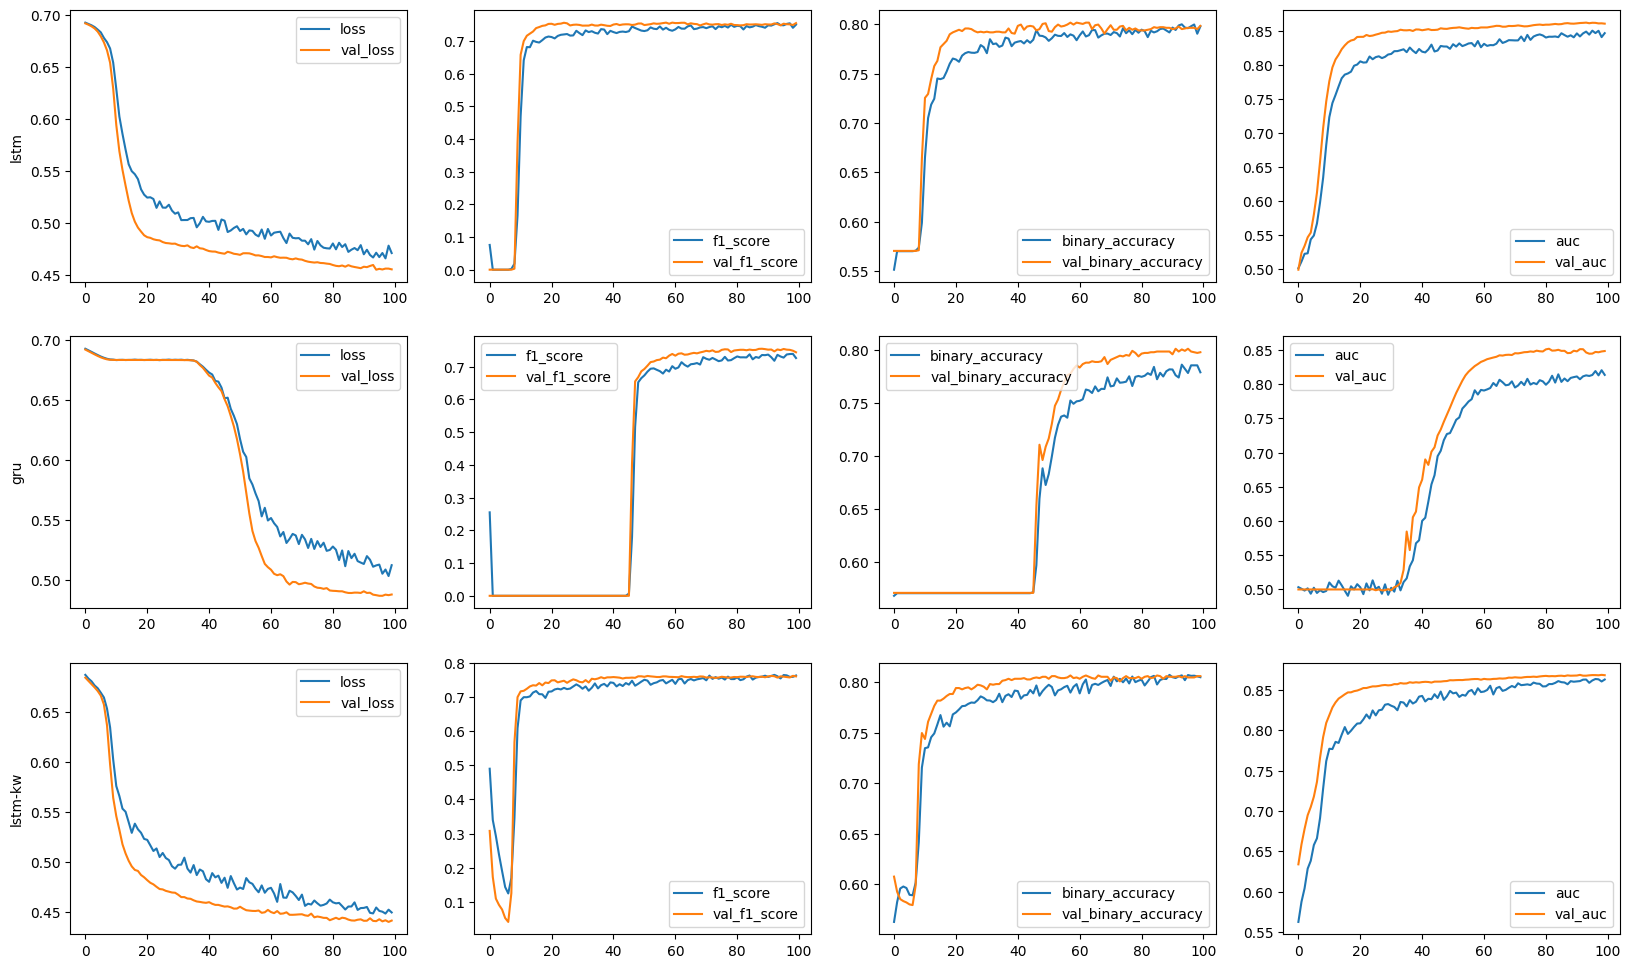

In [32]:
metrics = ['loss','f1_score','binary_accuracy','auc']
model_names = ['lstm', 'gru', 'lstm-kw']

stats = {
    'lstm': history_lstm.history,
    'gru': history_gru.history,
    'lstm-kw': history_lstm_kw.history
}


n = len(model_names)
m = len(metrics)

fig, axes = plt.subplots(n,m,figsize=(m*5,n*4))

for i,model_name in enumerate(model_names):
    for j,metric in enumerate(metrics):
        axes[i][0].set_ylabel(model_name)
        axes[i][j].plot(stats[model_name][metric], label=metric)
        axes[i][j].plot(stats[model_name]['val_'+metric], label='val_'+metric)
        axes[i][j].legend()
        

plt.show()

## Hyperparameters Tuning

I was actually curious if changing the number of LSTU units or the number of neurons in the dense layer would affect the model performance.

In [33]:
from datetime import datetime

probe_rnn_units = [32, 64, 96]
probe_dense_units = [32, 64, 96]

histories = dict()

for ru in probe_rnn_units:
    for du in probe_dense_units:

        model_lstm_kw_tune = make_lstm_kw_model(rnn_units=ru, dense_units=du)
        model_lstm_kw_tune.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=1e-4), metrics=shared_metrics)
        model_name = f'lstm-kw-ru{ru}-du{du}'

        history_lstm_kw_tune = model_lstm_kw_tune.fit(
            [X_text_train, X_keyword_train],y_train,
            batch_size=512, epochs=100, verbose=0,
            validation_data=([X_text_valid, X_keyword_valid],y_valid))
        histories[model_name] = history_lstm_kw_tune.history



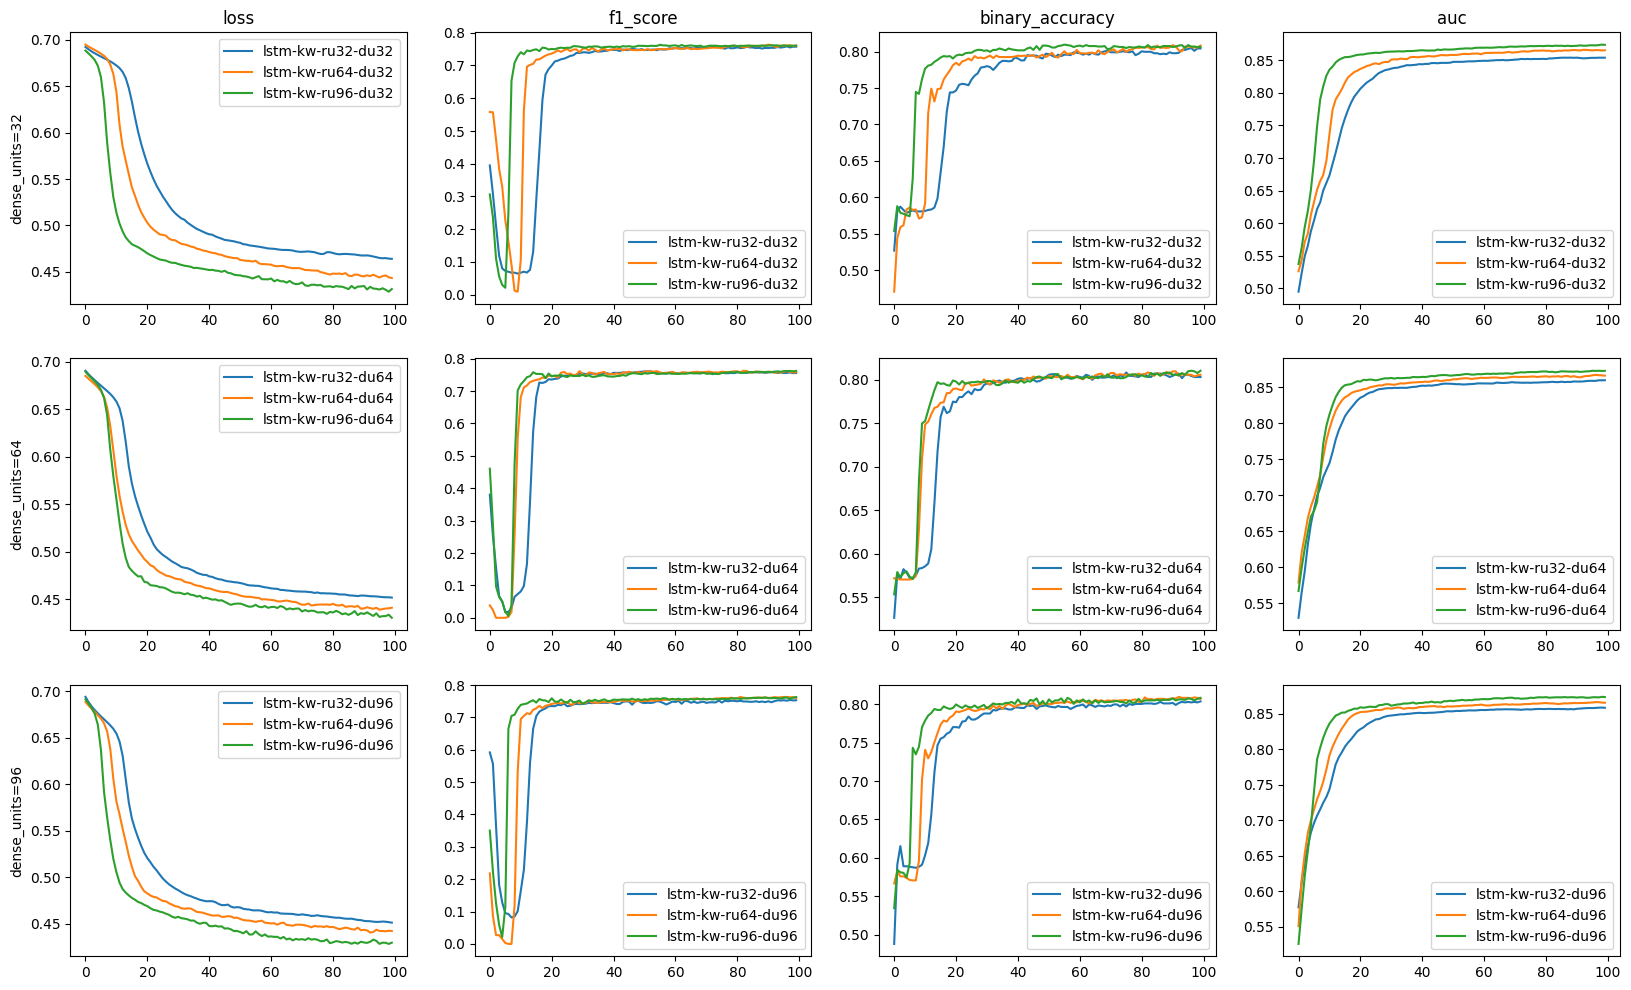

In [34]:
metrics = ['loss','f1_score','binary_accuracy','auc']

n = len(probe_dense_units)
m = len(metrics)

fig, axes = plt.subplots(n,m,figsize=(m*5,n*4))

for i,du in enumerate(probe_dense_units):
    axes[i][0].set_ylabel(f'dense_units={du}')
    
    for j,metric in enumerate(metrics):
        axes[0][j].set_title(metric)
        
        for ru in probe_rnn_units:
            model_name = f'lstm-kw-ru{ru}-du{du}'
            axes[i][j].plot(histories[model_name]['val_'+metric], label=model_name)
            
        axes[i][j].legend()
        
plt.show()

To me it looks like they all converge to the same final result according to *F1 score* metric. But the models with mode units converge faster.

# Conclusion

In this competition I could only get to the first 250 with the best score **0.80907**, but the final position in the leaderboard wasn't the goal per se - practicing NLP and learning RNN concepts was much more valuable.

If the goal was to climb higher, then the other things I would try:
* Geolocation. The `location` column could be used to obtain longitude and latitude, or some other numerical signals.
* Crawling http://t.co/xxx links, checking if they are leading to a reputable news websites
* Proper clustering of keywords (MiniLM results), or at least PCA/SVD to compress the dimensions and save on training speed.